# 02: Fleet exploratory analysis

1. What is the fleet — states, phases, capacity, coverage?
2. Where does it sit relative to the AS/NZS 4777.2 response thresholds?
3. How many intervals survive to the Volt-VAr detection window?
4. **Does the fleet actually do Volt-VAr?** — the question that determines whether
   conformance scoring in D9 is measuring a response or measuring noise.
5. What is the `derating_active` flag, and can it support Method C at D14?

In [17]:
# Reload edited .py modules without restarting the kernel.
# The library carries all the logic, so it gets edited constantly while notebooks
# stay thin -- without this, every module change means a kernel restart and a
# re-run of the expensive cells.
#
# CAVEAT: autoreload rebinds FUNCTIONS, not objects already constructed at import
# time. If you change a dataclass in se_params (SEAnalysisConfig, SEVoltVarParams)
# or a constant in se_config, restart the kernel -- `CONFIG` and `PARAMS` are
# module-level instances and will still be the old ones.
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents)
     if (p / "solar_edge").is_dir() and (p / "bms_sa_review").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate the CICCADA repository root from {_current}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from solar_edge.config import se_config as C
from solar_edge.lib import se_store, se_contract as contract, se_params
from solar_edge.lib import se_metadata as meta
from solar_edge.lib import se_queries as q
from solar_edge.lib import se_plots as plots

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

con = se_store.connect()
config = se_params.CONFIG
params = se_params.PARAMS
display(se_store.store_status(con)[["logical_name", "exists", "size_mb", "n_rows"]])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,logical_name,exists,size_mb,n_rows
0,se_interval,True,1470.8,86640968.0
1,se_interval_phase,False,NaN,NaN
2,se_site,True,0.0,1602.0
3,se_site_capacity,True,0.1,1600.0
4,bom_solar,False,NaN,NaN
5,se_structured,False,NaN,NaN
6,se_ghi_model,False,NaN,NaN
7,se_uncurtailedpv,False,NaN,NaN
8,se_conformance_voltvar,False,NaN,NaN
9,se_conformance_voltwatt,False,NaN,NaN


## 0. The manifest

Note the `substitution` rows. They record what this delivery does **not** have —
nameplate capacity, a flexible-export flag, irradiance — so their absence is explicit
rather than inferred from a default.

In [18]:
display(contract.manifest(config, params))

,section,setting,value
0,convention,active power: source convention,"generator (production magnitude, always >= 0)"
1,convention,active power: sign applied,+1 (no change)
2,convention,reactive power: source convention,load (positive = absorbing / inductive)
3,convention,reactive power: sign applied,-1 (flip)
4,convention,target convention,generator (AS/NZS 4777.2 Fig 3.2; negative Q =...
5,convention,basis for the reactive sign,"empirical Volt-VAr slope, single-phase cohort;..."
6,convention,active power units,W -> kW
7,convention,reactive power units,var -> kvar (instantaneous; NOT multiplied by 12)
8,convention,raw timestamp frame,"per-site local civil time, INCLUDING daylight ..."
9,convention,state -> timezone,"New South Wales = Australia/Sydney, South Aust..."


## 1. Build or refresh the site dimension

`s_99` is the 99th percentile of observed apparent power, ported from
`build_s99_estimates.py`. It is an **empirical observation, not a manufacturer
rating** — a site that never reached its inverter limit will have an `s_99` below it,
which biases the apparent-limit test toward finding symptoms. That is why the quantile
is swept in D15.

In [19]:
# Rebuilds only if se_site was built against a different store.
# Pass force=True to rebuild regardless.
meta.refresh_dimensions(con)

checks = meta.check_site_dimension(con)
display(checks)

meta.assert_checks(checks, label="D4")
display(meta.site_summary(con))

Site dimension is current with se_interval - no rebuild needed.


,check,expected,observed,pass,note
0,se_site is current with se_interval,not stale,current,True,se_site was built against a different store. R...
1,se_site has one row per site,"1,602","1,602",True,
2,site_alias unique,"1,602","1,602",True,
3,every site has a timezone,0 nulls,0,True,
4,every site has a postcode,0 nulls,0,True,
5,phase count is 1 or 3,0 others,0,True,"2-phase would mean a dropped phase, not a real..."
6,se_site_capacity covers every estimable site,"1,600","1,600",True,2 site(s) in the store have no interval with S...
7,s_99 positive everywhere,0 bad,0,True,
8,s_99 >= p_99 within tolerance,0 violations beyond 1% of p_99,0 (max gap 0.169%),True,"S = sqrt(P^2+Q^2) >= P exactly, but s_99 and p..."
9,geography attached (optional),"1,602 or 0 (pending shapefile)",0,True,D12 irradiance needs this; D5/D6 do not


D4: 10/10 checks passed


,state,n_sites,n_single_phase,n_three_phase,n_postcodes,median_s_99_kVA,median_p_99_kW,median_pct_days,n_night_anomaly
0,South Australia,574,408,166,153,5.01,5.00,100.0,6
1,New South Wales,570,468,102,202,5.75,5.73,100.0,8
2,Queensland,458,311,147,152,6.71,6.62,100.0,6


## 2. Fleet composition and coverage

,state,n_sites,single_phase,three_phase,pct_three_phase,n_postcodes,n_night_anomaly
0,South Australia,574,408,166,28.9,153,6
1,New South Wales,570,468,102,17.9,202,8
2,Queensland,458,311,147,32.1,152,6


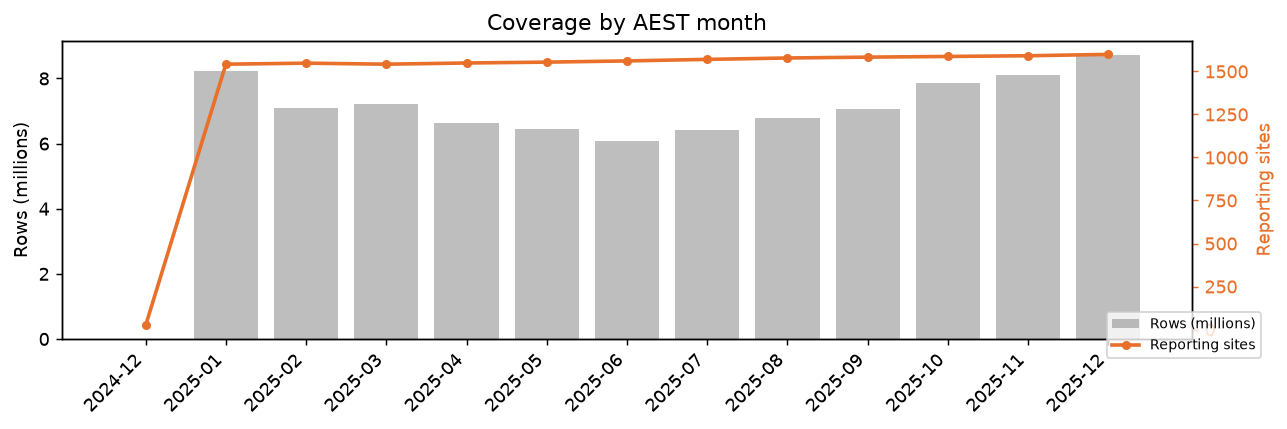

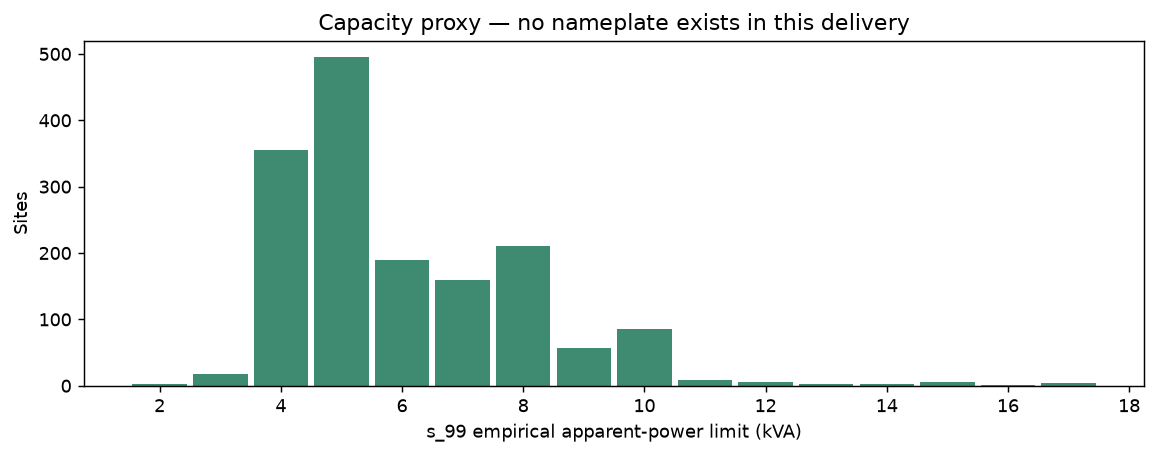

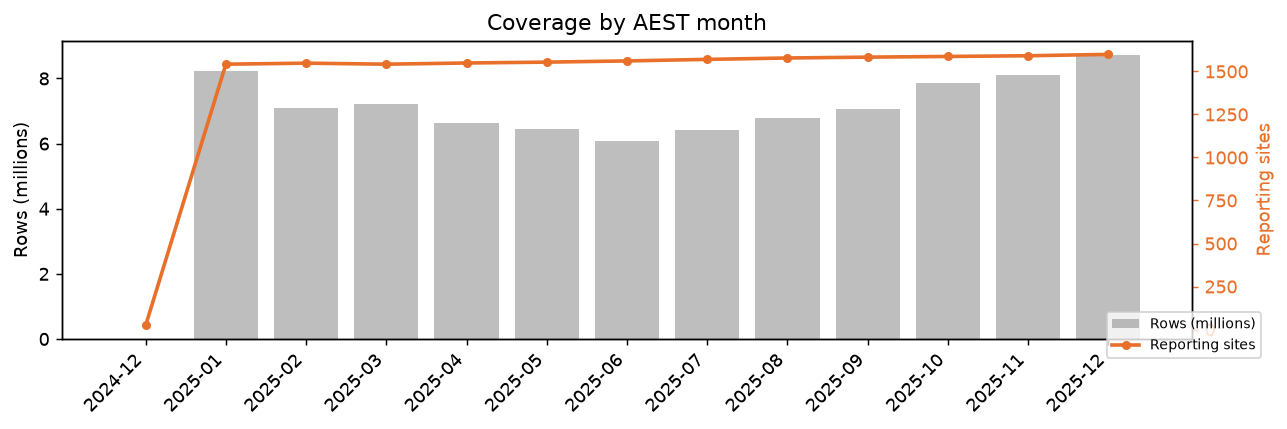

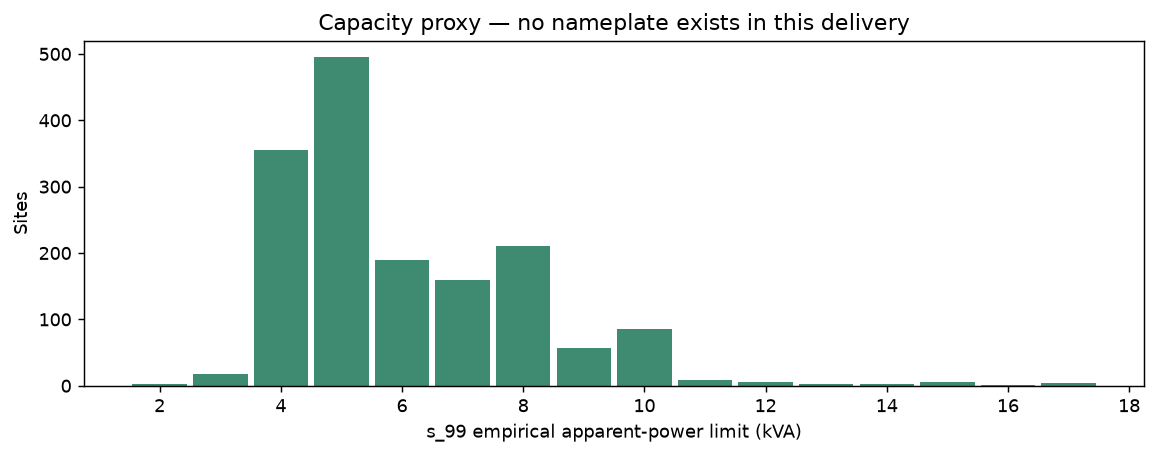

In [20]:
display(q.fleet_composition(con))

coverage = q.monthly_coverage(con)
display(plots.plot_monthly_coverage(coverage))

capacity = q.capacity_distribution(con)
display(plots.plot_capacity_distribution(capacity))

## 3. Timezone resolution check

The fleet diurnal profile in the AEST analysis frame. It must peak at hour 12. A double
hump or a smeared peak would mean the three states were pooled in mismatched frames.

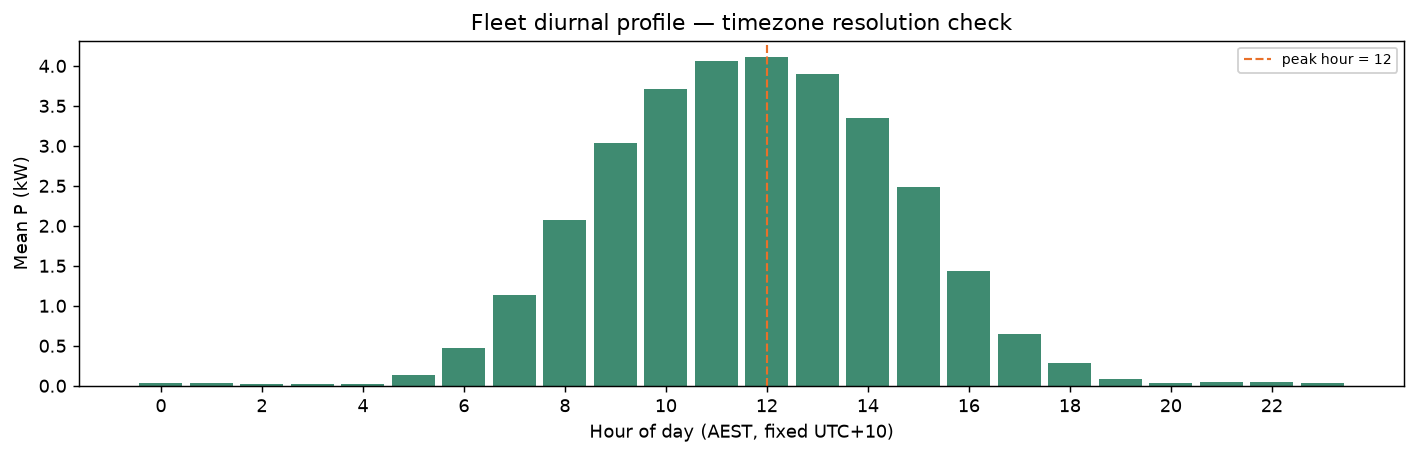

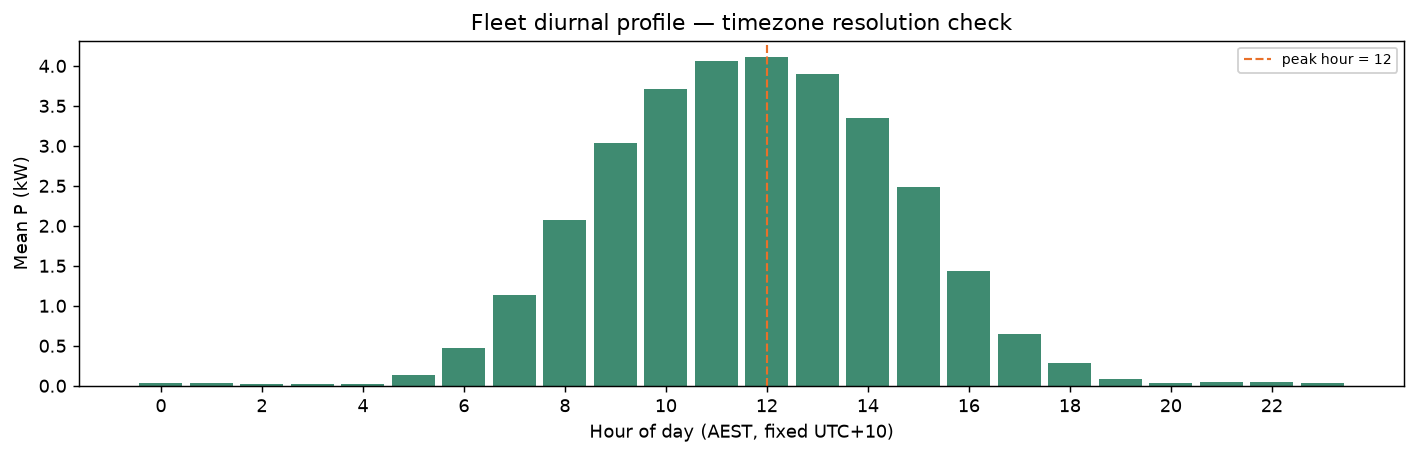

In [21]:
diurnal = q.diurnal_profile(con)
display(plots.plot_diurnal_profile(diurnal))

## 4. Where the fleet sits relative to the thresholds

This table sizes every downstream claim.

The **240–253 V band** is where Volt-VAr absorption is required and Volt-Watt has not
yet engaged — the window in which Volt-VAr-induced curtailment can be isolated. The
**253–258 V overlap** is where both respond at once; the project notes record that
empirical disaggregation there has no published precedent, which is why the analysis
restricts to 240–253 V.

,band,band_order,n_intervals,n_sites,pct_of_intervals
0,below V1 (Volt-VAr supply region),0,668,214,0.001
1,V1-V2 supply ramp (207-220 V),1,18566,254,0.022
2,V2-V3 deadband (220-240 V),2,21012600,1550,24.637
3,V3-VW1 Volt-VAr absorb only (240-253 V),3,63441572,1580,74.383
4,VW1-VVAR4 overlap (253-258 V),4,814171,682,0.955
5,above VVAR4 (258 V+),5,2745,161,0.003


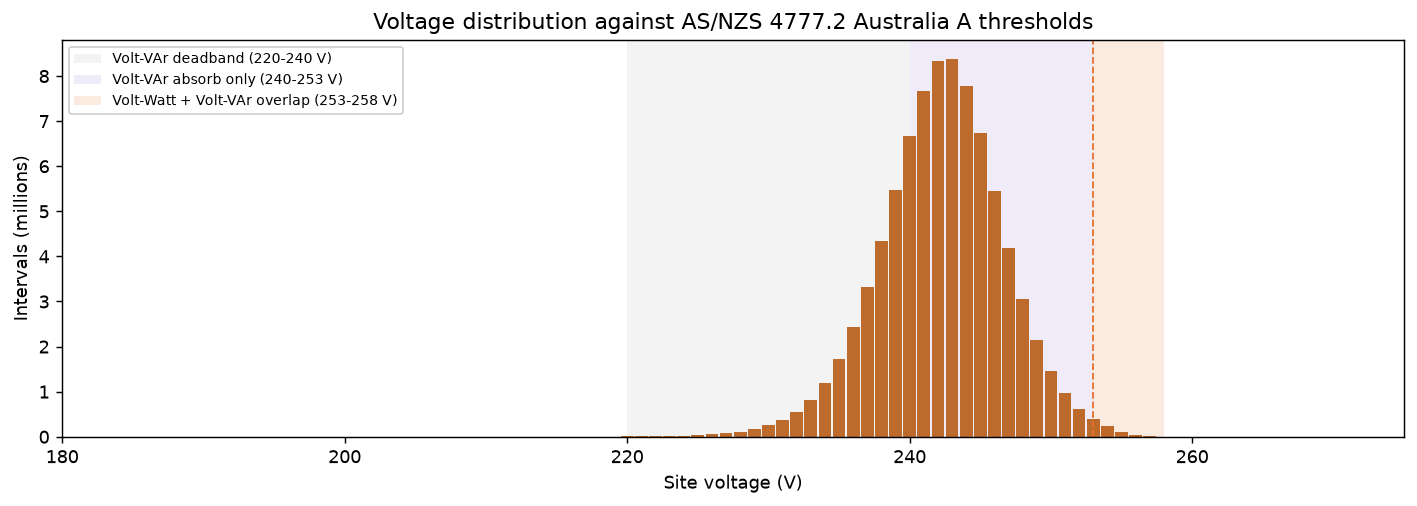

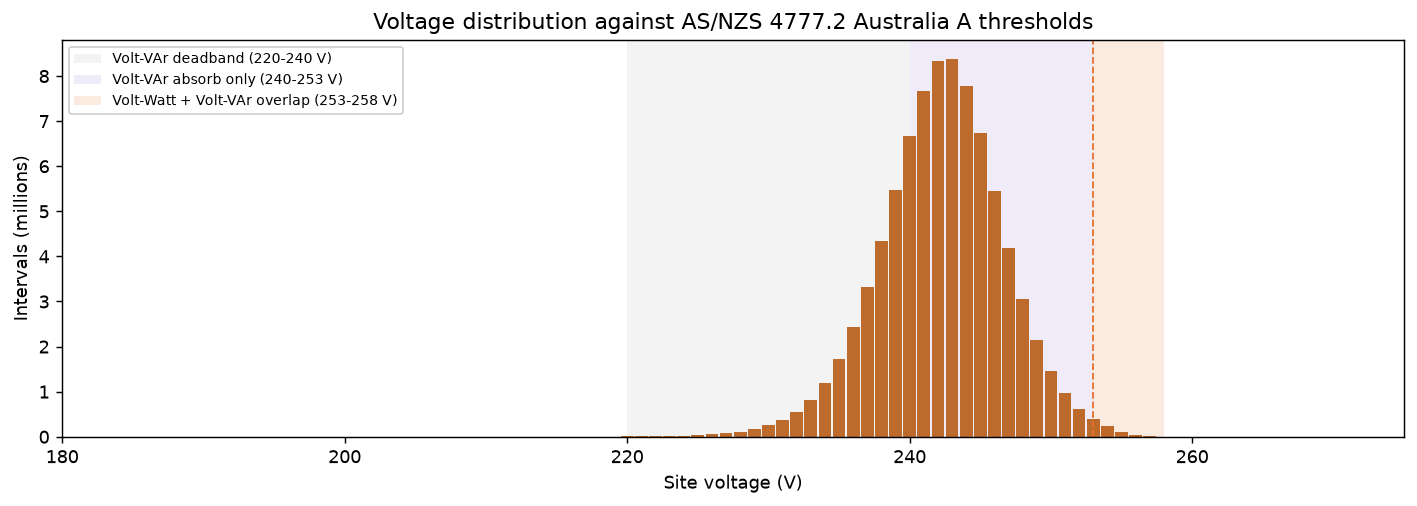

In [22]:
bands = q.voltage_band_occupancy(con, config)
display(bands)

vdist = q.voltage_distribution(con, config)
display(plots.plot_voltage_distribution(vdist))

## 5. Cohort funnel

Attrition from the whole store down to the detection window, in the same spirit as
`fetch_population_funnel` in the Solar Analytics work: never present a final count
without showing what it was drawn from.

In [23]:
display(q.cohort_funnel(con, config, params))

,stage,n_intervals,n_sites,pct_of_all
0,1. all stored intervals,86640968,1602,100.0000
1,2. cohort filters applied,85290322,1580,98.4411
2,3. + peak-solar window,20098673,1580,23.1977
3,4. + Volt-VAr voltage band,16579938,1580,19.1364
4,5. + absorbing reactive power (Q < 0),10465158,1114,12.0788


## 6. Does the fleet do Volt-VAr?

The most consequential section in this notebook.

In the CICCADA generator convention a conforming inverter **absorbs** reactive power
(Q < 0) above 240 V, so the median should slope **downward** with rising voltage. This
is also the fleet-scale check on the D2 sign flip.

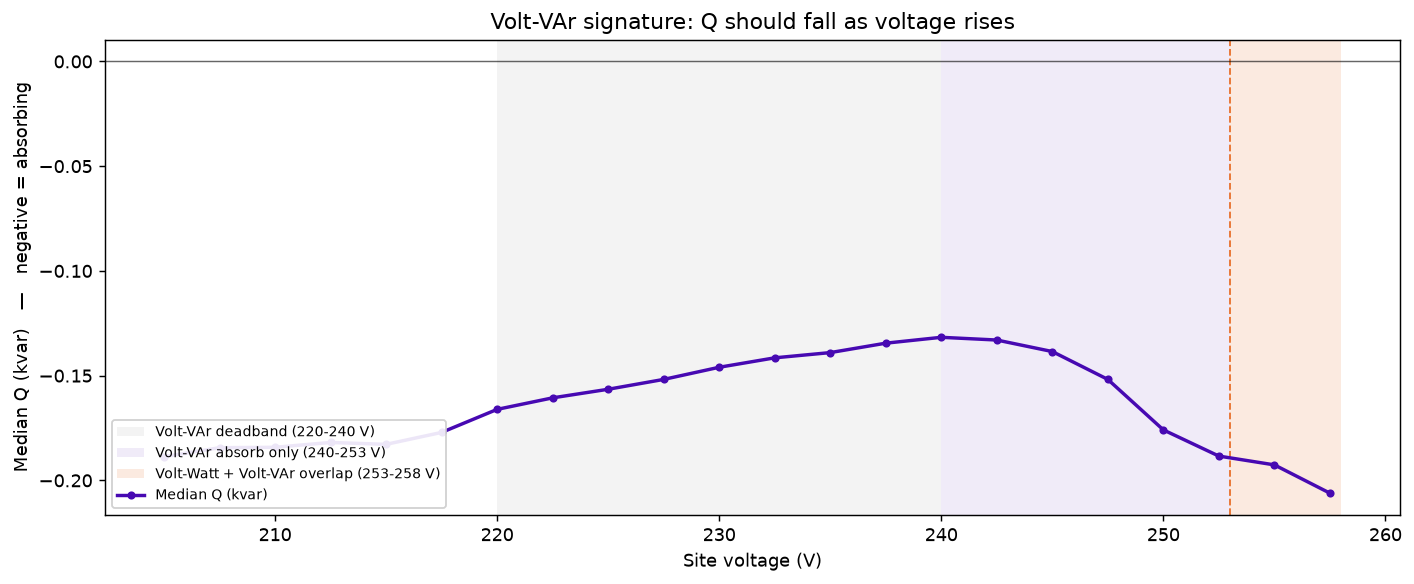

,v_bin,n_intervals,n_sites,median_Q_kvar,mean_Q_kvar,pct_absorbing,mean_P_kW
0,205.0,121,17,-0.1887,-0.2319,100.00,0.920
1,207.5,263,22,-0.1844,-0.2206,100.00,0.869
2,210.0,560,46,-0.1842,-0.2242,98.93,1.194
3,212.5,1318,78,-0.1819,-0.2085,94.92,1.309
4,215.0,2813,124,-0.1828,-0.2255,99.08,1.323
5,217.5,6357,201,-0.1771,-0.1916,98.44,1.408
6,220.0,14283,286,-0.1661,-0.1742,97.61,1.394
7,222.5,31460,433,-0.1606,-0.1618,95.64,1.376
8,225.0,74263,612,-0.1565,-0.1477,93.59,1.346
9,227.5,193463,817,-0.1518,-0.1336,91.59,1.323


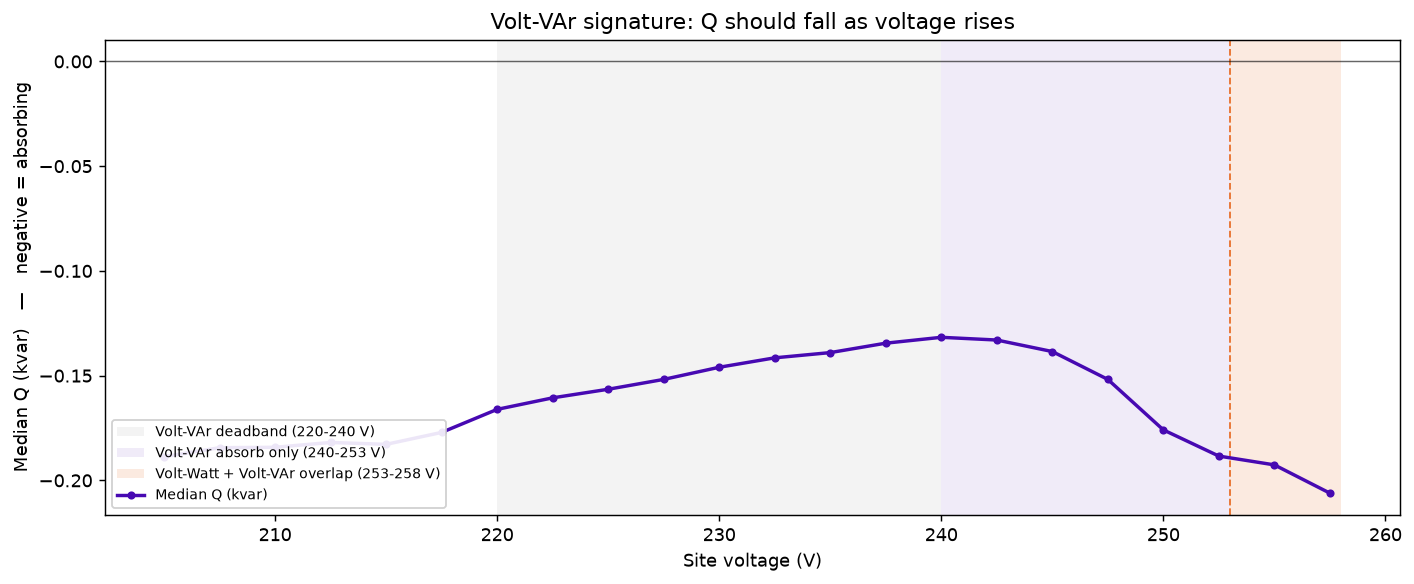

In [24]:
signature = q.voltvar_signature(con, config)
display(plots.plot_voltvar_signature(signature))
display(signature)

### 6a. Volt-VAr response, or fixed power factor?

A confound worth ruling out explicitly: site voltage **rises when the site exports
more**, so any reactive power proportional to P traces an apparent slope against
voltage without any Volt-VAr function being active at all.

The discriminator:

- `med_Q_over_P` flat across voltage → fixed power factor, no response
- `med_abs_Q_kvar` rising with voltage → genuine Volt-VAr behaviour

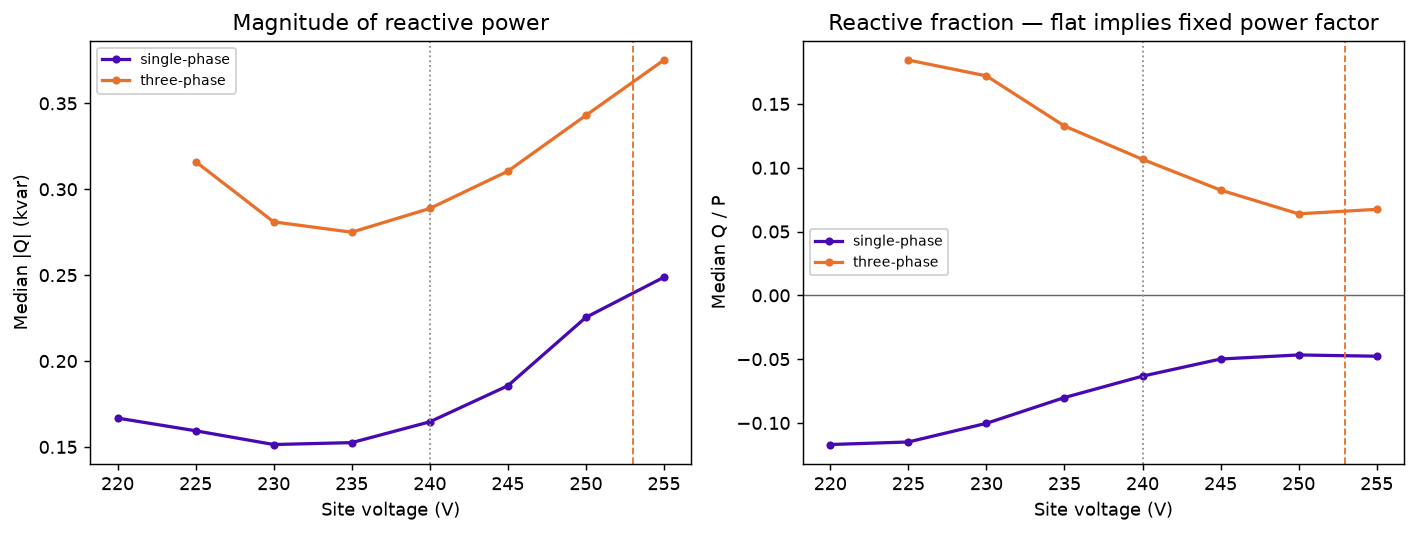

,cohort,v_bin,n_intervals,med_P_kW,med_Q_kvar,med_abs_Q_kvar,med_Q_over_P,med_power_factor
0,single-phase,220.0,31876,1.331,-0.1655,0.1668,-0.1169,0.9929
1,single-phase,225.0,183252,1.291,-0.1572,0.1594,-0.1149,0.9928
2,single-phase,230.0,1432444,1.387,-0.1480,0.1514,-0.1003,0.9942
3,single-phase,235.0,8161784,1.689,-0.1483,0.1525,-0.0801,0.9961
4,single-phase,240.0,20313892,2.251,-0.1519,0.1646,-0.0633,0.9968
5,single-phase,245.0,12859229,3.526,-0.1699,0.1856,-0.0499,0.9983
6,single-phase,250.0,2615113,4.509,-0.2053,0.2254,-0.0467,0.9987
7,single-phase,255.0,134730,4.286,-0.2159,0.2488,-0.0477,0.9984
8,three-phase,225.0,6922,1.542,0.3105,0.3161,0.1844,0.9816
9,three-phase,230.0,141490,1.598,0.2800,0.2810,0.1720,0.9850


Median power factor by cohort:


cohort
single-phase    0.99645
three-phase     0.99420
Name: med_power_factor, dtype: float64

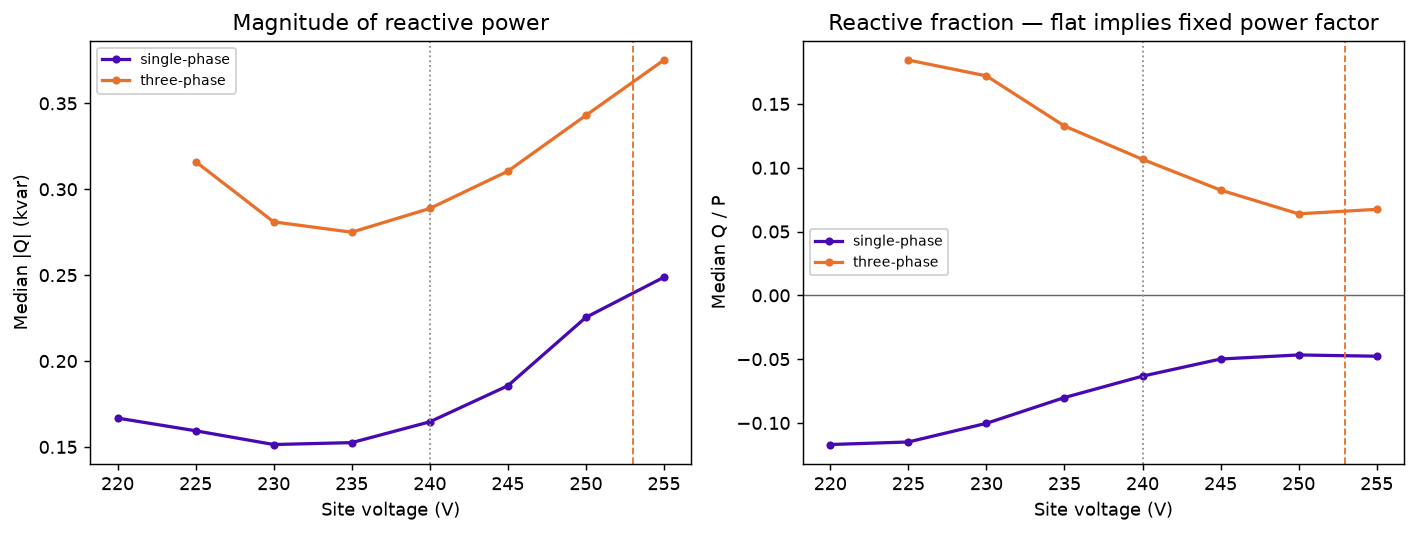

In [25]:
character = q.reactive_character(con, config)
display(plots.plot_reactive_character(character))
display(character)

print("Median power factor by cohort:")
display(character.groupby("cohort").med_power_factor.median())

### 6b. Single-phase versus three-phase

Flagged during the D2 sign-convention work and still unresolved. The two cohorts move in
**opposite reactive directions**, and three-phase sites are about a quarter of the fleet.

Measured on the full year (see the `reactive_character` table above):

| | single-phase | three-phase |
|---|---|---|
| Median Q at 220–225 V | **−0.166 kvar** (absorbing) | **+0.311 kvar** (supplying) |
| Median Q at 255 V | **−0.216 kvar** | **+0.370 kvar** |
| Median \|Q\| minimum | 0.151 kvar at 230–235 V | 0.275 kvar at 235 V |
| Median power factor | 0.993–0.999 | 0.982–0.998 |

The detail that matters is the third row. **Both cohorts show a minimum in \|Q\| at
230–235 V**, rising on either side — the shape of a Volt-VAr deadband, sitting almost
exactly where AS/NZS 4777.2 puts it (220–240 V). The two curves are close to mirror
images of each other.

That similarity is the point. A cohort responding genuinely *adversely* would not be
expected to reproduce the standard's own deadband geometry; a cohort whose reactive sign
is reported with the opposite polarity would reproduce it exactly, inverted. The evidence
therefore leans toward a **reporting-sign difference in three-phase inverters**, not
toward 405 sites actively doing the wrong thing.

It is not proof, and the consequences of getting it wrong run in opposite directions:

- if the sign is inverted, flipping it makes the cohort broadly conformant, and failing
  to flip would report a spurious fleet-wide non-conformance;
- if the response is genuinely adverse, flipping it would erase a real and significant
  conformance finding.

Aggregate medians cannot settle this. It needs SolarEdge documentation on three-phase
reactive-power sign reporting, or one site with known ground truth.

In [26]:
display(q.phase_cohort_comparison(con, config))

,cohort,v_band,n_intervals,n_sites,median_Q_kvar,pct_absorbing
0,single-phase,high (>250 V),2764932,851,-0.2054,88.50
1,single-phase,low (<235 V),2224089,1025,-0.1479,93.36
2,single-phase,mid (235-250 V),46316431,1165,-0.1541,87.98
3,three-phase,high (>250 V),954843,305,0.3435,1.06
4,three-phase,low (<235 V),196002,281,0.2970,1.44
5,three-phase,mid (235-250 V),17580658,415,0.2980,1.18


## 7. The `derating_active` flag

An inverter-reported power-limitation signal with no Solar Analytics counterpart. If it
is voltage-driven it corroborates the Volt-Watt / Volt-VAr story; a flat baseline at
ordinary voltages is something else — thermal, DC clipping, or export limiting — and
must not be attributed to grid response.

Recall from D3 that the raw column is `1.0` or NULL, never `0.0`. "Not derating" and
"not reported" are indistinguishable, so **precision against this flag is interpretable
but recall is not**. Method C at D14 has to state that.

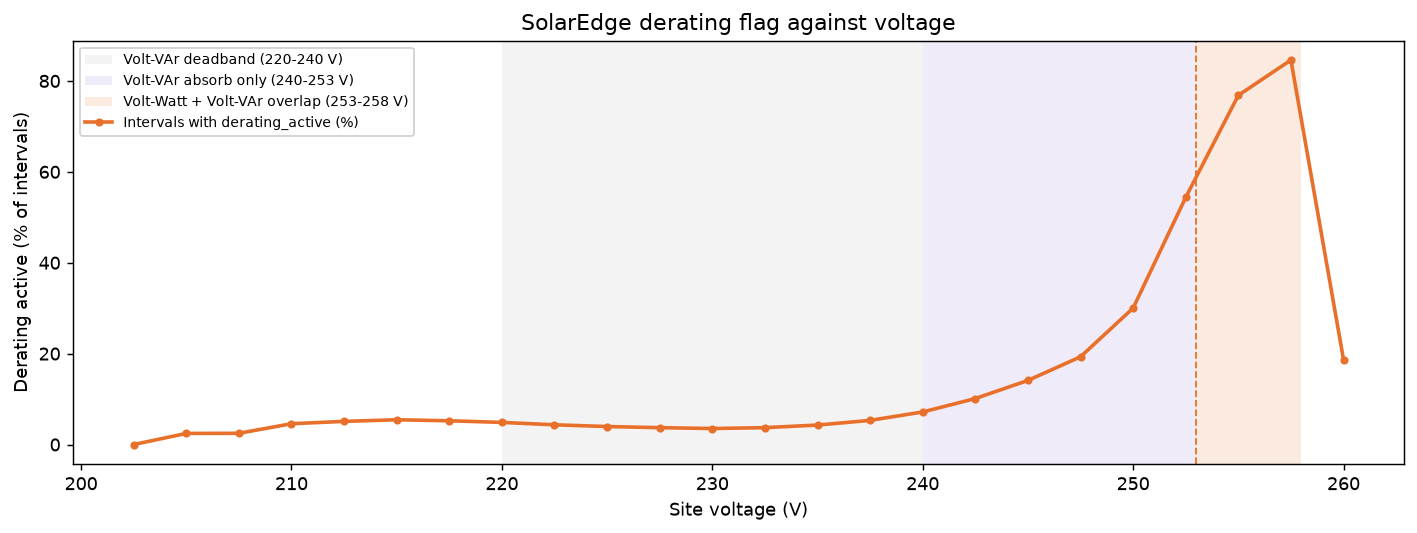

,v_bin,n_intervals,n_derating,pct_derating,mean_P_kW,mean_P_derating
0,202.5,128,0,0.000,0.463,NaN
1,205.0,205,5,2.439,0.565,1.913
2,207.5,445,11,2.472,0.535,1.196
3,210.0,961,44,4.579,0.716,2.970
4,212.5,2140,109,5.093,0.824,2.992
5,215.0,4628,252,5.445,0.823,2.909
6,217.5,10337,540,5.224,0.886,3.108
7,220.0,23300,1134,4.867,0.875,3.089
8,222.5,51917,2253,4.340,0.854,3.053
9,225.0,123529,4885,3.955,0.829,2.883


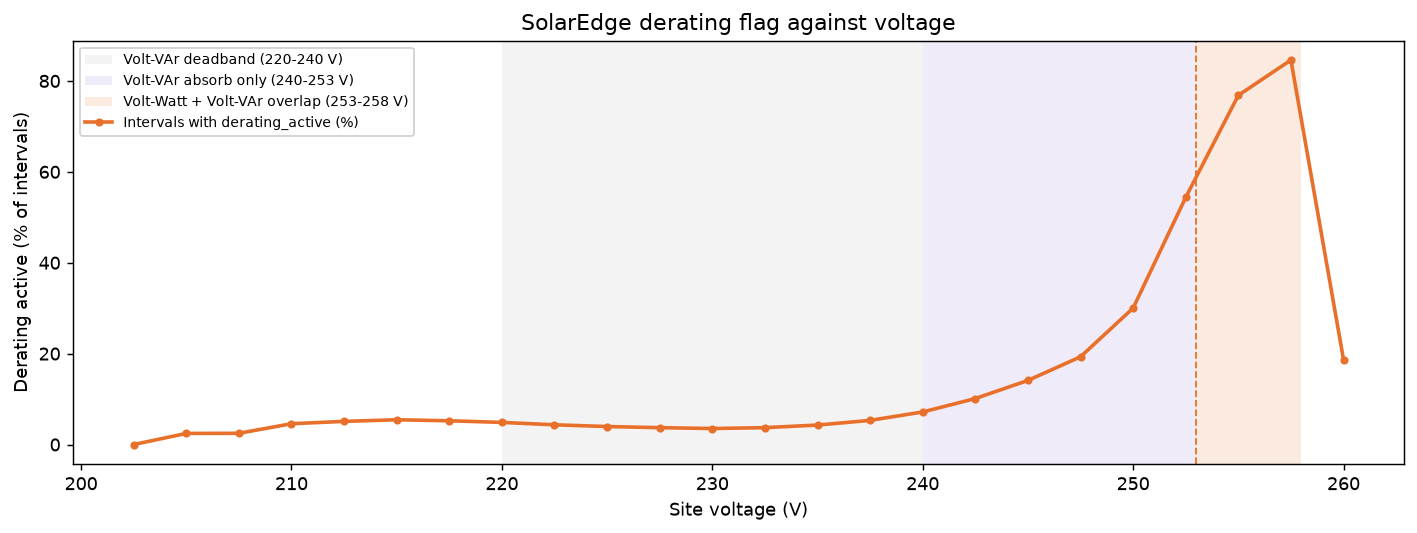

In [27]:
derating = q.derating_by_voltage(con, config)
display(plots.plot_derating_by_voltage(derating))
display(derating)

In [28]:
display(q.derating_by_cohort(con, config))

,cohort,generation_level,n_intervals,n_derating,pct_derating
0,single-phase,at or above 50% of p_99,21538776,6477215,30.072
1,single-phase,below 50% of p_99,32452147,2076390,6.398
2,single-phase,not generating,7535599,50230,0.667
3,three-phase,at or above 50% of p_99,7562455,619165,8.187
4,three-phase,below 50% of p_99,11947986,30481,0.255
5,three-phase,not generating,4253359,6126,0.144


## 8. Sensitivity of the cohort to its own definition

`with_changes()` makes a sweep cheap. Here: how much does the eligible population move
when the cohort definition moves? If a headline number is fragile to these, D15 needs to
say so.

In [15]:
variants = {
    "default": config,
    "voltage = mean of phases": config.with_changes(voltage_aggregation="mean"),
    "single-phase only": config.with_changes(phase_cohort="single"),
    "three-phase only": config.with_changes(phase_cohort="three"),
    "exclude derating intervals": config.with_changes(derating_selection="exclude"),
    "include night-anomaly sites": config.with_changes(night_anomaly_selection="include"),
    "sites with >= 300 days": config.with_changes(min_days_observed=300),
}

rows = []
for label, variant in variants.items():
    funnel = q.cohort_funnel(con, variant, params)
    band = funnel.iloc[3]
    rows.append({
        "variant": label,
        "cohort_intervals": int(funnel.iloc[1].n_intervals),
        "in_voltvar_window": int(band.n_intervals),
        "sites_in_window": int(band.n_sites),
    })
display(pd.DataFrame(rows))

,variant,cohort_intervals,in_voltvar_window,sites_in_window
0,default,85290322,16579938,1580
1,voltage = mean of phases,85290322,16165611,1579
2,single-phase only,61526522,11922806,1165
3,three-phase only,23763800,4657132,415
4,exclude derating intervals,76030715,12326263,1580
5,include night-anomaly sites,86640785,16795496,1600
6,sites with >= 300 days,82908898,16108854,1501


## 9. Data-quality report (D7)

Every known issue quantified against an explicit threshold, run against the **built
store** so it reports what the analysis will actually see.

Two kinds of row, and the distinction is the point:

- **`ok` / `WARN`** — measurable defects with a threshold. These can pass or fail.
- **`STRUCTURAL`** — properties of the delivery that cannot be fixed and must be carried
  as stated limitations: no nameplate, no irradiance, a derating flag with no explicit
  zero, sparse overnight coverage, timestamps off a common grid.

The structural rows are listed here precisely so that a clean quality report cannot be
mistaken for a complete dataset.

In [16]:
from solar_edge.lib import se_diagnostics as diag

quality = diag.data_quality_report(con)
display(quality)

n_warn = int((quality.status == "WARN").sum())
n_struct = int((quality.status == "STRUCTURAL").sum())
print(f"{n_warn} warnings, {n_struct} structural limitations")

quality.to_csv(C.ARTEFACT_DIR / "data_quality_report.csv", index=False)
print(f"Written to {C.ARTEFACT_DIR / 'data_quality_report.csv'}")

,issue,measure,value,threshold,status,note
0,voltage missing,% intervals with NULL V_max,0.0000%,< 1%,ok,
1,voltage zero,% intervals with V_max <= 0,0.0000%,< 0.1%,ok,"zeros are inverter-off states, not measurement..."
2,voltage implausibly high,% intervals with V_max > 270 V,0.0000%,< 0.01%,ok,
3,voltage implausibly low,% intervals with 0 < V_max < 180 V,0.0003%,< 0.1%,ok,
4,active power missing,% intervals with NULL P_kW,0.0000%,< 1%,ok,
5,active power negative,% intervals with P_kW < 0,0.0000%,0%,ok,SolarEdge reports production magnitude; any ne...
6,reactive power missing,% intervals with NULL Q_kvar,0.0000%,< 5%,ok,
7,frequency out of range,% intervals outside 45-55 Hz,0.0006%,< 0.01%,ok,
8,no phase reporting,% intervals with zero phases,0.0000%,< 0.1%,ok,
9,night-time generation (mis-framed timestamps),% intervals with P > 0.5 kW at 21:00-04:00 AEST,0.0255% across 20 sites,< 0.1%,ok,excluded by default via night_anomaly_selectio...


0 warnings, 5 structural limitations
Written to C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\data_quality_report.csv


## What this establishes

- **Population is ample** for the Volt-VAr work: about three quarters of all intervals
  sit in the 240–253 V band, and roughly 1,580 sites survive the cohort filters.
- **The Volt-Watt population is thin** — under 1% of intervals above 253 V, and a few
  thousand above 258 V. D10 conformance rates there will carry wide intervals, and that
  should be stated rather than discovered later.
- **Timezone resolution holds at fleet scale** — the diurnal profile peaks at hour 12.
- **Fleet-median reactive power is small**, with power factor around 0.995–0.997 in both
  cohorts. The strong Volt-VAr responders found during D2 are a minority. Conformance
  rates in D9 must be read against how little most of this fleet is doing.
- **The derating flag is strongly voltage-driven**, which is what makes Method C worth
  building at D14.

## Open question for D9

The single- and three-phase cohorts move in opposite reactive directions. Before the two
are pooled in conformance scoring, this needs resolving — either SolarEdge documentation
on three-phase reactive sign reporting, or a site with known ground truth.

Until then D9 should score the cohorts **separately** and report them separately. Pooling
them would average a real response against its mirror image and understate both.

## Next: D7 — data-quality report

Quantifies the nine issues catalogued in the architecture proposal against explicit
thresholds, including the 20 night-anomaly sites from D3.